In [25]:
# Visualize Phase-2 output bounding boxes per page (independent cell)
# Place/run this from: medrecs_pipeline/phase_2/

import io
import json
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw


In [26]:

# ---------- Config ----------
ROOT = Path.cwd().resolve()  # expected: .../medrecs_pipeline/phase_2
PIPELINE_ROOT = ROOT.parent  # .../medrecs_pipeline

# Input PDF used in Phase-2
PDF_PATH = PIPELINE_ROOT / "data" / "input_phase_2" / "input_1.pdf"

# New Phase-2 structured output
# update doc_id if your output filename differs
DOC_ID = "doc_input_1"
STRUCTURED_JSON = (
    PIPELINE_ROOT
    / "data"
    / "output_phase_2"
    / "structured_documents"
    / f"{DOC_ID}_structured_document.json"
)

PAGE_TO_VIEW = 25     # change page number
DPI_VIZ = 150         # use same DPI as extraction
SAVE_IMAGE = True     # set False if you don't want to save file

TYPE_COLORS = {
    "HEADER": "#2563eb",
    "TEXT": "#16a34a",
    "TABLE": "#ea580c",
    "IMAGE": "#9333ea",
    "CHECKBOX": "#ca8a04",
    "SIGNATURE": "#dc2626",
    "BARCODE": "#0891b2",
    "FOOTER": "#64748b",
}


In [27]:

# ---------- Helpers ----------
def render_page(pdf_path: Path, page_number: int, dpi: int) -> Image.Image:
    doc = fitz.open(pdf_path)
    try:
        page = doc[page_number - 1]
        pix = page.get_pixmap(matrix=fitz.Matrix(dpi / 72, dpi / 72), alpha=False)
        return Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    finally:
        doc.close()

def resolve_structured_json(path: Path, fallback_dir: Path):
    if path.exists():
        return path
    candidates = sorted(fallback_dir.glob("*_structured_document.json"))
    if not candidates:
        raise FileNotFoundError(f"No structured output found in: {fallback_dir}")
    print(f"[info] Using fallback structured JSON: {candidates[0].name}")
    return candidates[0]


In [28]:

# ---------- Load ----------
structured_dir = PIPELINE_ROOT / "data" / "output_phase_2" / "structured_documents"
STRUCTURED_JSON = resolve_structured_json(STRUCTURED_JSON, structured_dir)

if not PDF_PATH.exists():
    raise FileNotFoundError(f"PDF not found: {PDF_PATH}")
if not STRUCTURED_JSON.exists():
    raise FileNotFoundError(f"Structured JSON not found: {STRUCTURED_JSON}")

doc_data = json.loads(STRUCTURED_JSON.read_text(encoding="utf-8"))
elements = [e for e in doc_data.get("elements", []) if e.get("page_number") == PAGE_TO_VIEW]
print(f"doc_id: {doc_data.get('document_id')} | total_pages: {doc_data.get('total_pages')}")
print(f"Page {PAGE_TO_VIEW}: {len(elements)} elements")

img = render_page(PDF_PATH, PAGE_TO_VIEW, DPI_VIZ)
w, h = img.size


doc_id: doc_input_1 | total_pages: 40
Page 25: 4 elements


In [29]:

# ---------- A) PIL reference ----------
pil_overlay = img.copy()
draw = ImageDraw.Draw(pil_overlay)

for el in elements:
    boxes = el.get("bounding_boxes") or []
    if not boxes:
        continue
    x0, y0, x1, y1 = boxes[0]
    color = TYPE_COLORS.get(el.get("element_type", "TEXT"), "#ef4444")
    draw.rectangle(
        [int(x0 * w), int(y0 * h), int(x1 * w), int(y1 * h)],
        outline=color,
        width=2,
    )


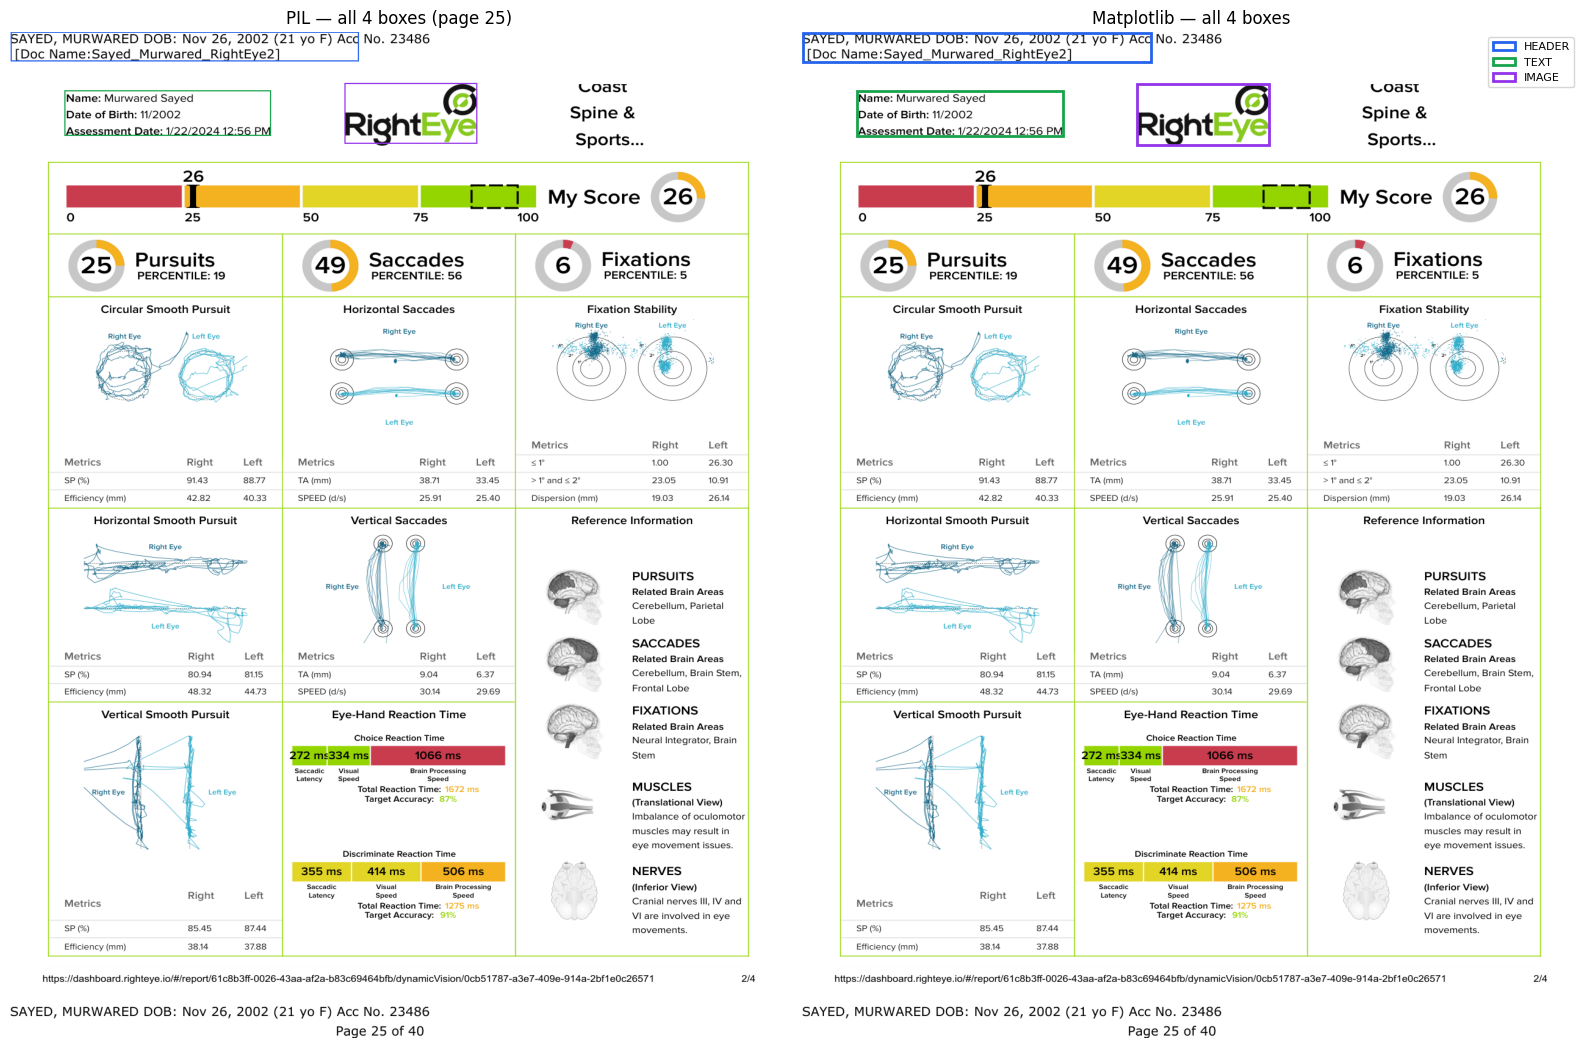

In [30]:

# ---------- B) Matplotlib ----------

fig, axes = plt.subplots(1, 2, figsize=(16, 13))

# left: PIL reference
axes[0].imshow(pil_overlay, extent=[0, w, h, 0], origin="upper")
axes[0].set_xlim(0, w)
axes[0].set_ylim(h, 0)
axes[0].set_aspect("equal")
axes[0].set_title(f"PIL — all {len(elements)} boxes (page {PAGE_TO_VIEW})")
axes[0].axis("off")

# right: matplotlib patches
axes[1].imshow(img, extent=[0, w, h, 0], origin="upper")
axes[1].set_xlim(0, w)
axes[1].set_ylim(h, 0)
axes[1].set_aspect("equal")

legend = {}
for el in elements:
    boxes = el.get("bounding_boxes") or []
    if not boxes:
        continue
    et = el.get("element_type", "TEXT")
    color = TYPE_COLORS.get(et, "#ef4444")
    x0, y0, x1, y1 = boxes[0]

    axes[1].add_patch(
        Rectangle(
            (x0 * w, y0 * h),
            (x1 - x0) * w,
            (y1 - y0) * h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
    )
    if et not in legend:
        legend[et] = Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=color, linewidth=2)

if legend:
    axes[1].legend(legend.values(), legend.keys(), loc="upper right", fontsize=8)
axes[1].set_title(f"Matplotlib — all {len(elements)} boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ---------- Optional save ----------
# if SAVE_IMAGE:
#     out_dir = PIPELINE_ROOT / "data" / "output_phase_2" / "visualizations"
#     out_dir.mkdir(parents=True, exist_ok=True)
#     out = out_dir / f"page_{PAGE_TO_VIEW:02d}_all_boxes_phase2.png"
#     pil_overlay.save(out)
#     print(f"Saved → {out}")